# Tomato Disease Classification

## 1. Import Required Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML

## 2. Set Constants

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50

## 3. Load and Explore the Tomato Dataset

Dataset is pre-split into `Train/`, `Val/`, and `Test/` directories. Each subdirectory contains one folder per class.

In [3]:
import pathlib

# Find the Crop-Care-AI project root regardless of where the kernel's CWD is.
# The project root always contains both "training/" and "api/" subdirectories.
_cwd = pathlib.Path().resolve()
_project_root = None
for _p in [_cwd] + list(_cwd.parents):
    if (_p / "training").is_dir() and (_p / "api").is_dir():
        _project_root = _p
        break
if _project_root is None:
    raise RuntimeError(f"Could not locate project root from CWD: {_cwd}")

DATA_DIR = str(_project_root.parent / "Data" / "Tomato")
print(f"Project root : {_project_root}")
print(f"DATA_DIR     : {DATA_DIR}")

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Train",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Val",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Test",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)
class_names = train_ds.class_names
print("Classes:", class_names)

Project root : D:\Development\Shravani\Crop-Care-AI
DATA_DIR     : D:\Development\Shravani\Data\Tomato
Found 11108 files belonging to 6 classes.
Found 2495 files belonging to 6 classes.
Found 280 files belonging to 6 classes.
Classes: ['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Septoria Leaf Spot', 'Yellow Leaf Curl Virus']


In [4]:
class_names = train_ds.class_names
print("Classes:", class_names)
print(f"\nTrain batches:      {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches:       {len(test_ds)}")

Classes: ['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Septoria Leaf Spot', 'Yellow Leaf Curl Virus']

Train batches:      348
Validation batches: 78
Test batches:       9


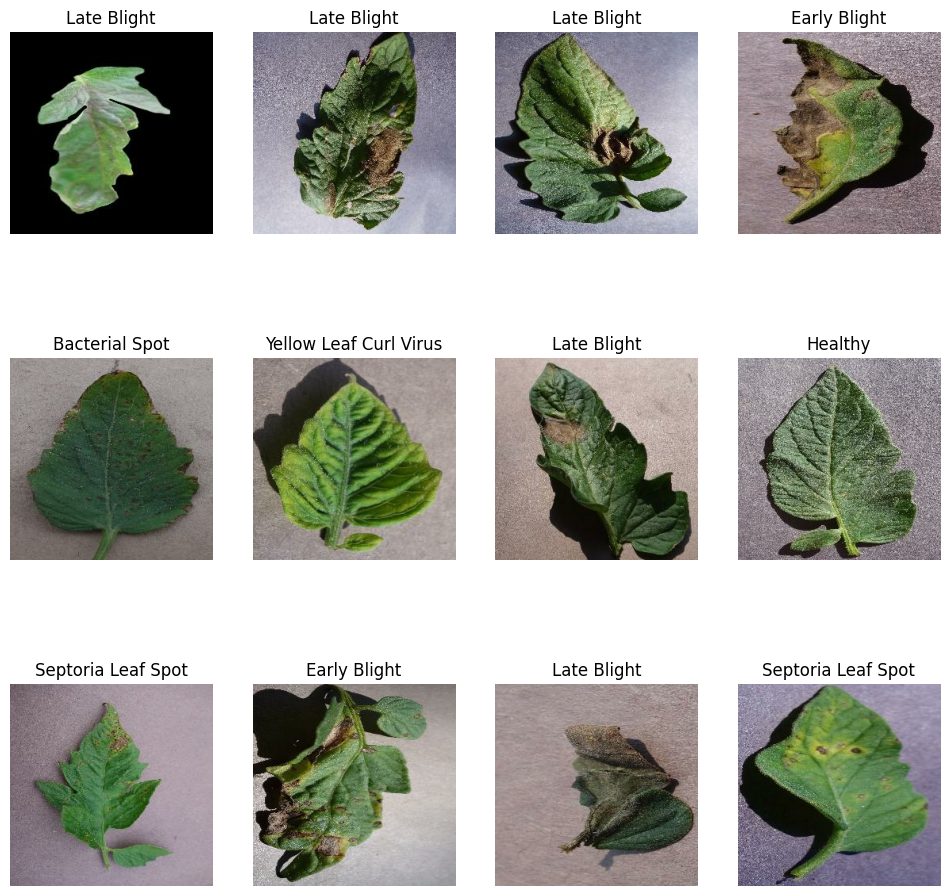

In [5]:
# Visualize sample images from the training set
plt.figure(figsize=(12, 12))
for image_batch, labels_batch in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

## 4. Preprocess the Data

### Cache, Shuffle, and Prefetch

In [6]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds  = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

### Resizing, Normalization and Data Augmentation Layers

In [7]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

# Apply augmentation only to training set
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

## 5. Build the Model

CNN architecture with resizing, normalization and data augmentation included as layers.

In [8]:
n_classes = len(class_names)  # 6 for Tomato
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)
model.summary()

C:\Users\Rohit Chaskar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 6)                     │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,942 (718.52 KB)

 Trainable params: 183,942 (718.52 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [9]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS,
)

Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - accuracy: 0.4680 - loss: 1.3105 - val_accuracy: 0.5122 - val_loss: 1.4809
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 456s 1s/step - accuracy: 0.6855 - loss: 0.8481 - val_accuracy: 0.5968 - val_loss: 1.4243
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.7786 - loss: 0.5845 - val_accuracy: 0.7395 - val_loss: 0.7505
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 495s 1s/step - accuracy: 0.8276 - loss: 0.4624 - val_accuracy: 0.7956 - val_loss: 0.5297
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.8565 - loss: 0.3826 - val_accuracy: 0.8469 - val_loss: 0.4156
Epoch 6/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 477s 1s/step - accuracy: 0.8755 - loss: 0.3380 - val_accuracy: 0.8485 - val_loss: 0.4043
Epoch 7/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 359s 1s/step - accuracy: 0.8875 - loss: 0.3124 - val_accuracy: 0.8525 - val_loss: 0.4214
Epoch 8/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.9011 - loss: 0.2654 - val_accu

## 7. Evaluate the Model

In [11]:
scores = model.evaluate(test_ds)
print(f"Test Loss:     {scores[0]:.4f}")
print(f"Test Accuracy: {scores[1]*100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 340ms/step - accuracy: 0.8857 - loss: 0.2579
Test Loss:     0.2579
Test Accuracy: 88.57%


## 8. Visualize Training Results

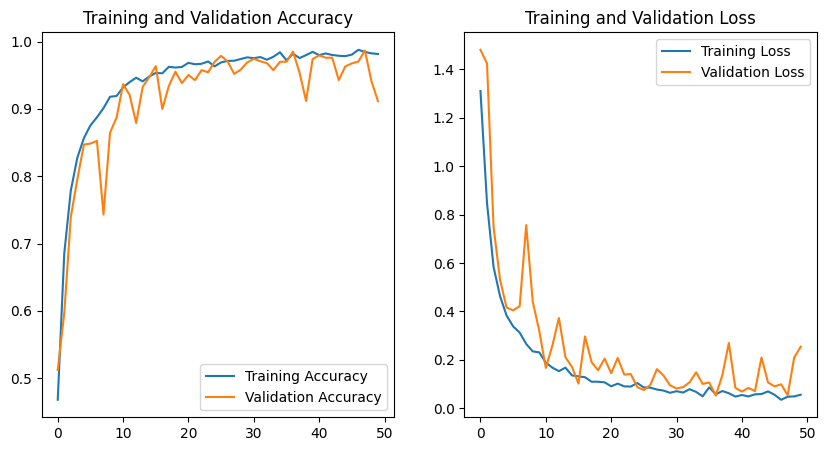

In [12]:
hist = dict(history.history)
acc     = hist['accuracy']
val_acc = hist['val_accuracy']
loss     = hist['loss']
val_loss = hist['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Run Predictions on Sample Test Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


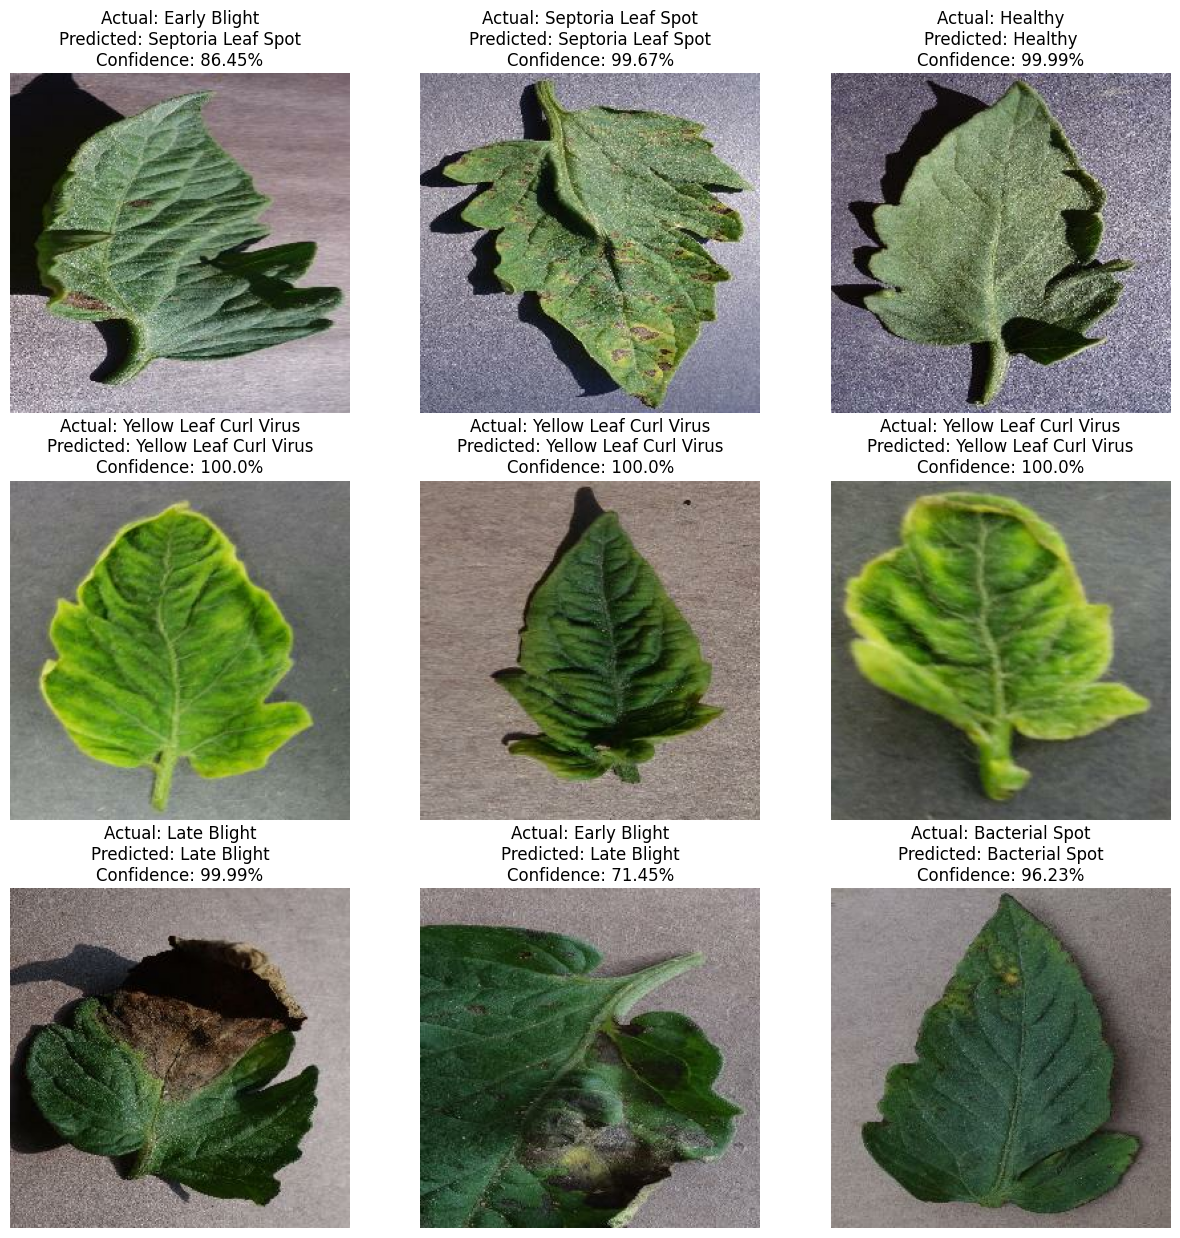

In [13]:
def predict(model, img):
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
        plt.axis("off")

## 9. Save the Model

In [ ]:
# Save
model.save("../tomato.keras")
print("Saved: ../tomato.keras")